In [51]:
# !pip install openml

In [52]:
from sklearn.datasets import fetch_openml

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
dataset = fetch_openml(data_id =  40996,cache = True)
# There are two parameters either give thename of the dataset from openml or give the data id from the openml
# and cache means if once downloaded then again when needed not download only reload it

In [55]:
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [56]:
print(dataset.keys())

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


In [57]:
X = dataset['data']  #  This data is the input variable/features

In [58]:
Y = dataset['target']  # the target the the label

In [59]:
dataset['frame']
# X and Y combine to combine to complete dataset called frame

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
1,0,0,0,0,0,1,0,0,0,0,...,114,130,76,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,22,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,33,96,...,0,0,0,0,0,0,0,0,0,3
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
69996,0,0,0,0,0,0,0,0,0,31,...,0,0,0,0,0,0,0,0,0,1
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [60]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [61]:
plt.rcParams['figure.figsize'] = (15,5)
plt.rcParams['figure.dpi'] = 100

In [62]:
class_indices = Y.unique()
class_indices = list(class_indices)
class_indices.sort()
class_indices

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

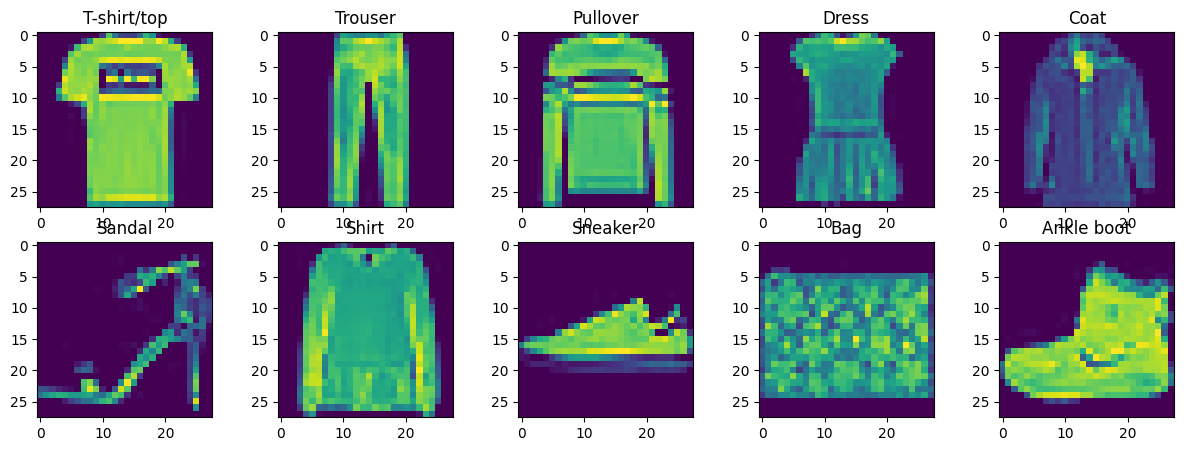

In [63]:
for i in class_indices:
  plt.subplot(2,5,int(i)+1)
  img = X[Y==i].iloc[0].to_numpy().reshape(28,28)
# We did the reshape to make the image in the form of 28*28 Pixels
  plt.title(class_names[int(i)])
  plt.imshow(img)


In [64]:
X,Y

(       pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
 0           0       0       0       0       0       0       0       0       0   
 1           0       0       0       0       0       1       0       0       0   
 2           0       0       0       0       0       0       0       0       0   
 3           0       0       0       0       0       0       0       0      33   
 4           0       0       0       0       0       0       0       0       0   
 ...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
 69995       0       0       0       0       0       0       0       0       0   
 69996       0       0       0       0       0       0       0       0       0   
 69997       0       0       0       0       0       0       0       0       0   
 69998       0       0       0       0       0       0       0       0       0   
 69999       0       0       0       0       0       0       0       0       0   
 
        pixel1

In [65]:
Y = Y.astype(int)

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
X_train,X_test,Y_train,Y_test = train_test_split(X/255,Y,test_size=0.2,random_state = 0)
# X features are in the range of 0 to 255 and deep learning neural network works better in the range of 0 to 1 so X/255

In [68]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [69]:
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((56000, 784), (14000, 784), (56000,), (14000,))

In [70]:
X_train.shape[1]

784

In [71]:
def get_model():
  model = Sequential()
  model.add(Flatten(input_shape=(X_train.shape[1],)))
  model.add(Dense(120,activation = 'relu'))
  model.add(Dense(64,activation = 'relu'))
  model.add(Dense(10,activation='softmax'))
  return model
  # Sigmoid is for binary classification
  # Softmax is for categorical classification

In [72]:
model = get_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [73]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        94,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,594 (400.76 KB)

 Trainable params: 102,594 (400.76 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_3, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>]

In [75]:
model.layers[1].get_weights()
# There are two arrays first one is weight and second one is bias. These are randonmly given weights before training and default bias = 0

[array([[-0.02887971, -0.03046859,  0.06361113, ..., -0.03664413,
         -0.02681661,  0.00542262],
        [ 0.0002769 , -0.02710031, -0.0490856 , ..., -0.03135842,
          0.06892118,  0.05438094],
        [-0.01797759, -0.07368468,  0.07141142, ...,  0.00617219,
         -0.03238549, -0.07992683],
        ...,
        [-0.02049909, -0.01614644,  0.06268854, ..., -0.03105163,
         -0.02244591,  0.06441092],
        [ 0.01476629, -0.01061912, -0.0442883 , ..., -0.02198118,
          0.06141029, -0.05812084],
        [ 0.05029853, -0.0672299 ,  0.0530881 , ...,  0.07854448,
         -0.00436547, -0.02621451]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

In [76]:
model.compile(optimizer='Adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [77]:
history = model.fit(X_train,Y_train,epochs=10,validation_data=(X_test,Y_test))

Epoch 1/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7693 - loss: 0.6633 - val_accuracy: 0.8464 - val_loss: 0.4109
Epoch 2/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8615 - loss: 0.3813 - val_accuracy: 0.8688 - val_loss: 0.3671
Epoch 3/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8741 - loss: 0.3401 - val_accuracy: 0.8761 - val_loss: 0.3340
Epoch 4/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8829 - loss: 0.3157 - val_accuracy: 0.8785 - val_loss: 0.3272
Epoch 5/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8895 - loss: 0.2965 - val_accuracy: 0.8811 - val_loss: 0.3292
Epoch 6/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8944 - loss: 0.2814 - val_accuracy: 0.8781 - val_loss: 0.3322
Epoch 7/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8964 - loss: 0.2698 - val_accuracy: 0.8846 - val_loss: 0.3231
Epoch 8/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9034 - loss: 0.2528 -

In [78]:
history.history

{'accuracy': [0.8184642791748047,
  0.8627499938011169,
  0.8741250038146973,
  0.8831250071525574,
  0.8883571624755859,
  0.8932142853736877,
  0.8969107270240784,
  0.9010178446769714,
  0.9040892720222473,
  0.9071071147918701],
 'loss': [0.5086479783058167,
  0.3756340444087982,
  0.3409525752067566,
  0.31590917706489563,
  0.30010583996772766,
  0.28454095125198364,
  0.2721526324748993,
  0.2617603838443756,
  0.25155338644981384,
  0.24136489629745483],
 'val_accuracy': [0.8463571667671204,
  0.8687857389450073,
  0.8760714530944824,
  0.8784999847412109,
  0.8810714483261108,
  0.8781428337097168,
  0.8846428394317627,
  0.881428599357605,
  0.8887143135070801,
  0.8792856931686401],
 'val_loss': [0.4108670949935913,
  0.36706608533859253,
  0.333971232175827,
  0.32720857858657837,
  0.32923606038093567,
  0.3321640193462372,
  0.32310810685157776,
  0.3256964683532715,
  0.3124581575393677,
  0.33843863010406494]}

In [79]:
class myCallBack(tf.keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs={}):
    if(logs.get('accuracy')-logs.get('val_accuracy')>=0.01):
      print("The validation accracy falls by 1% and training is being cancelled")
      self.model.stop_training = True
callbacks = myCallBack()
model.fit(X_train,Y_train,epochs = 10,validation_data=(X_test,Y_test),callbacks = [callbacks])

Epoch 1/10
1742/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9123 - loss: 0.2309The validation accracy falls by 1% and training is being cancelled
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9123 - loss: 0.2309 - val_accuracy: 0.8924 - val_loss: 0.3121


**Saving and loading the model**

perhaps the model will provide the index corresponding to them class names/target names are also required to save

In [80]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [81]:
model_classes = {'model':model,'classes':class_names}

In [81]:
import pickle as pkl

In [83]:
pickle.dump(model_classes,open('model_classes.pkl','wb'))

In [87]:
loaded_model = pickle.load(open('model_classes.pkl','rb'))

In [88]:
loaded_model

{'model': <Sequential name=sequential_1, built=True>,
 'classes': ['T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot']}

In [96]:
X_test

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
10840,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
56267,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
14849,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.113725,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
62726,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
47180,0.0,0.0,0.0,0.0,0.0,0.000000,0.019608,0.349020,0.462745,0.588235,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.121569,0.262745,0.184314,0.015686,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29357,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
52488,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.082353,...,0.505882,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
9603,0.0,0.0,0.0,0.0,0.0,0.003922,0.000000,0.003922,0.003922,0.000000,...,0.066667,0.054902,0.000000,0.003922,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
34949,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.137255,...,0.439216,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0


In [101]:
X_test.iloc[0]

,10840
pixel1,0.0
pixel2,0.0
pixel3,0.0
pixel4,0.0
pixel5,0.0
...,...
pixel780,0.0
pixel781,0.0
pixel782,0.0
pixel783,0.0


In [111]:
pred = loaded_model['model'].predict(X_test.iloc[0].to_numpy().reshape(1,784))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [117]:
pred

array([[1.02870129e-10, 7.27992111e-11, 1.28141031e-09, 5.64327529e-10,
        1.77841644e-10, 1.89733509e-08, 9.63039981e-10, 1.23656555e-05,
        1.26059484e-11, 9.99987602e-01]], dtype=float32)

In [115]:
idx = np.argmax(pred[0])

In [118]:
idx

np.int64(9)

In [119]:
loaded_model['classes'][9]

'Ankle boot'

In [116]:
idx

np.int64(9)

In [107]:
X_test.iloc[0].to_numpy().reshape(1,784)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [110]:
X_test.iloc[0].to_numpy()

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [120]:
# np.argmax returns the index of the maximum value in numpy array